# AdaBoost - Model Development Workflow

> **MLCourse · Machine Learning · supervised · classification**

Production tuning on REAL breast-cancer data: staged performance curve,
learning_rate × n_estimators trade-off, stump vs slightly-deeper base learner.

### What you'll learn
- `staged_predict`: accuracy as rounds accumulate
- The lr↔rounds seesaw (same total budget, different pacing)
- When the weak learner should stop being weak

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

base = AdaBoostClassifier(n_estimators=200, learning_rate=0.8,
                          random_state=42).fit(X_tr, y_tr)
pred = base.predict(X_te)
print(f"test acc {accuracy_score(y_te, pred):.4f}")
cv = cross_val_score(base, X_tr, y_tr, cv=5).mean()
print(f"CV acc   {cv:.4f}")
pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

test acc 0.9650


CV acc   0.9671


,pred malignant,pred benign
true malignant,49,4
true benign,1,89


### 1. Staged accuracy - does round 200 still help?


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


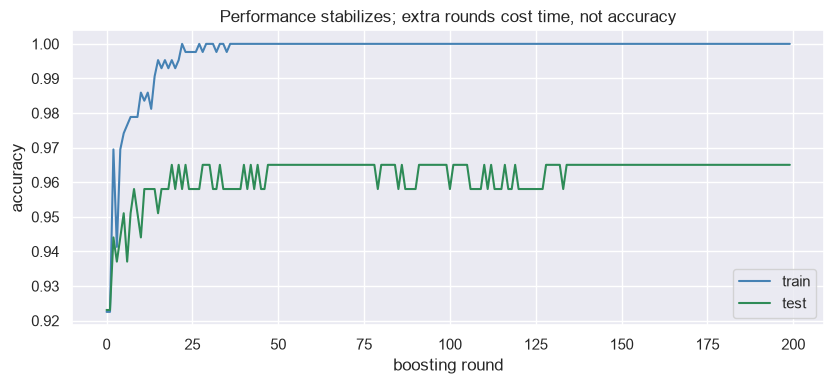

In [2]:
staged_tr = list(base.staged_score(X_tr, y_tr))
staged_te = list(base.staged_score(X_te, y_te))

plt.figure(figsize=(8.5, 4))
plt.plot(staged_tr, label="train", color="steelblue")
plt.plot(staged_te, label="test", color="seagreen")
plt.xlabel("boosting round"); plt.ylabel("accuracy")
plt.title("Performance stabilizes; extra rounds cost time, not accuracy")
plt.legend(); plt.tight_layout(); plt.show()

### 2. learning_rate × n_estimators grid


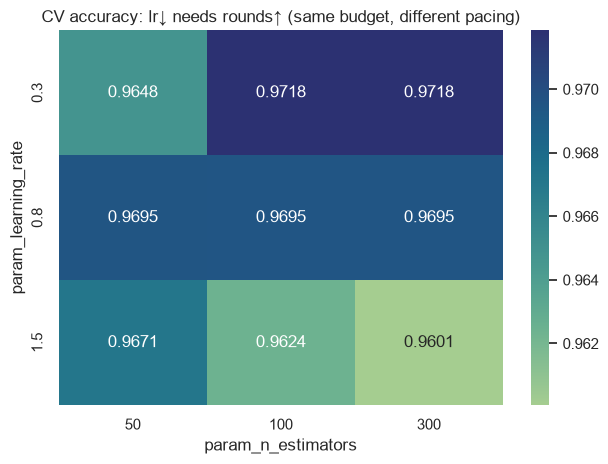

best: {'learning_rate': 0.3, 'n_estimators': 100} | CV 0.9718


In [3]:
grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    {"n_estimators": [50, 100, 300],
     "learning_rate": [0.3, 0.8, 1.5]},
    cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)
res = pd.DataFrame(grid.cv_results_)
pivot = res.pivot_table(index="param_learning_rate",
                        columns="param_n_estimators", values="mean_test_score")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="crest")
plt.title("CV accuracy: lr↓ needs rounds↑ (same budget, different pacing)")
plt.tight_layout(); plt.show()
print("best:", grid.best_params_, f"| CV {grid.best_score_:.4f}")

### 3. How weak should the weak learner be?


In [4]:
for depth in [1, 2, 3]:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth),
        n_estimators=200, learning_rate=0.8,
        random_state=42)
    cv = cross_val_score(m, X_tr, y_tr, cv=5).mean()
    print(f"base depth={depth}: CV {cv:.4f}")
print("depth-1 stumps usually suffice; deeper bases drift toward GBM territory.")

base depth=1: CV 0.9671


base depth=2: CV 0.9648


base depth=3: CV 0.9624
depth-1 stumps usually suffice; deeper bases drift toward GBM territory.


### Summary & key takeaways

- Staged scores reveal the point of diminishing boosting returns.
- learning_rate scales each α_t: halve it, double rounds - same family.
- Keep the base learner WEAK; strength belongs to the ensemble.
- On clean data AdaBoost ≈ RF; on noisy data it can chase bad labels.